# Table 7 Log Bolometric Luminosity Versus Redshift

This notebook reads `table_7.csv` from the `jaxsedfit` repository root, estimates `L_2500A` from the Table 7 UV variability parameters, and plots the corresponding estimated `log10(L_bol)` as a function of redshift.

## Setup

Run this notebook from `jaxsedfit/notebooks` or from the repository root. The helper below finds the checkout root automatically.

In [9]:
from pathlib import Path
import csv
import os


def find_jaxsedfit_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "jaxsedfit").is_dir() and (path / "table_7.csv").is_file():
            return path
        nested = path / "jaxsedfit"
        if (nested / "src" / "jaxsedfit").is_dir() and (nested / "table_7.csv").is_file():
            return nested
    raise RuntimeError("Could not find the jaxsedfit repository root with table_7.csv")


ROOT = find_jaxsedfit_root()
TABLE7_PATH = ROOT / "table_7.csv"
OUTPUT_DIR = ROOT / "notebook_outputs" / "16_log_bolometric_luminosity_redshift"
MPLCONFIG_DIR = OUTPUT_DIR / "mplconfig"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

print(f"Repository root: {ROOT}")
print(f"Reading: {TABLE7_PATH}")

Repository root: /home/nicho/GRAHSP/jaxsedfit
Reading: /home/nicho/GRAHSP/jaxsedfit/table_7.csv


## Load Table 7 And Estimate Luminosity

This uses the variability-luminosity relation:

`L_2500A = (9.3e44 erg/s) * (sigma_UV / 0.2 mag)^(-2.52) * (tau_UV,RF / 800 days)^(0.62)`

Table 7 stores `log_sigma_UV` and `log_tau_UV_RF`, so the notebook treats those as base-10 logs of `sigma_UV` and `tau_UV,RF`. To keep the requested bolometric-luminosity plot, it then applies a configurable bolometric correction:

`L_bol = BC_2500 * L_2500A`

The default is `BC_2500 = 5.15`; change that value below if you want a different correction.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

L2500_NORM = 9.3e44
L2500_NORM_ERR = 0.4e44
SIGMA_UV_NORM = 0.2
TAU_UV_RF_NORM_DAYS = 800.0
SIGMA_EXPONENT = -2.52
SIGMA_EXPONENT_ERR = 0.06
TAU_EXPONENT = 0.62
TAU_EXPONENT_ERR = 0.033
BOL_CORRECTION_2500 = 5.15


def as_float(value):
    if value is None or value == "":
        return np.nan
    try:
        return float(value)
    except ValueError:
        return np.nan


with TABLE7_PATH.open(newline="") as handle:
    rows = list(csv.DictReader(handle))

sdss_name = np.array([row["SDSS Name"] for row in rows])
redshift = np.array([as_float(row["z"]) for row in rows])
log_sigma_uv = np.array([as_float(row["log_sigma_UV"]) for row in rows])
log_sigma_uv_err = np.array([as_float(row["log_sigma_UV_err"]) for row in rows])
log_tau_uv_rf = np.array([as_float(row["log_tau_UV_RF"]) for row in rows])
log_tau_uv_rf_err = np.array([as_float(row["log_tau_UV_RF_err"]) for row in rows])

log_sigma_ratio = log_sigma_uv - np.log10(SIGMA_UV_NORM)
log_tau_ratio = log_tau_uv_rf - np.log10(TAU_UV_RF_NORM_DAYS)

log_l2500 = (
    np.log10(L2500_NORM)
    + SIGMA_EXPONENT * log_sigma_ratio
    + TAU_EXPONENT * log_tau_ratio
)
log_lbol = np.log10(BOL_CORRECTION_2500) + log_l2500

log_l2500_err = np.sqrt(
    (L2500_NORM_ERR / (L2500_NORM * np.log(10)))**2
    + (log_sigma_ratio * SIGMA_EXPONENT_ERR)**2
    + (SIGMA_EXPONENT * log_sigma_uv_err)**2
    + (log_tau_ratio * TAU_EXPONENT_ERR)**2
    + (TAU_EXPONENT * log_tau_uv_rf_err)**2
)
log_lbol_err = log_l2500_err

valid = np.isfinite(redshift) & np.isfinite(log_lbol)

print(f"Loaded {len(rows):,} AGNs from Table 7")
print(f"Valid redshift and estimated logLbol values: {valid.sum():,}")
print(f"Redshift range: {np.nanmin(redshift):.3f} to {np.nanmax(redshift):.3f}")
print(f"Estimated logL2500 range: {np.nanmin(log_l2500):.3f} to {np.nanmax(log_l2500):.3f}")
print(f"Estimated logLbol range: {np.nanmin(log_lbol):.3f} to {np.nanmax(log_lbol):.3f}")
print(f"Using BC_2500 = {BOL_CORRECTION_2500}")

Loaded 6,007 AGNs from Table 7
Valid redshift and estimated logLbol values: 6,007
Redshift range: 0.200 to 3.648
Estimated logL2500 range: 43.681 to 46.923
Estimated logLbol range: 44.393 to 47.635
Using BC_2500 = 5.15


## Plot Estimated Log Bolometric Luminosity Versus Redshift

Saved figure to /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/16_log_bolometric_luminosity_redshift/table7_variability_logLbol_vs_redshift.png


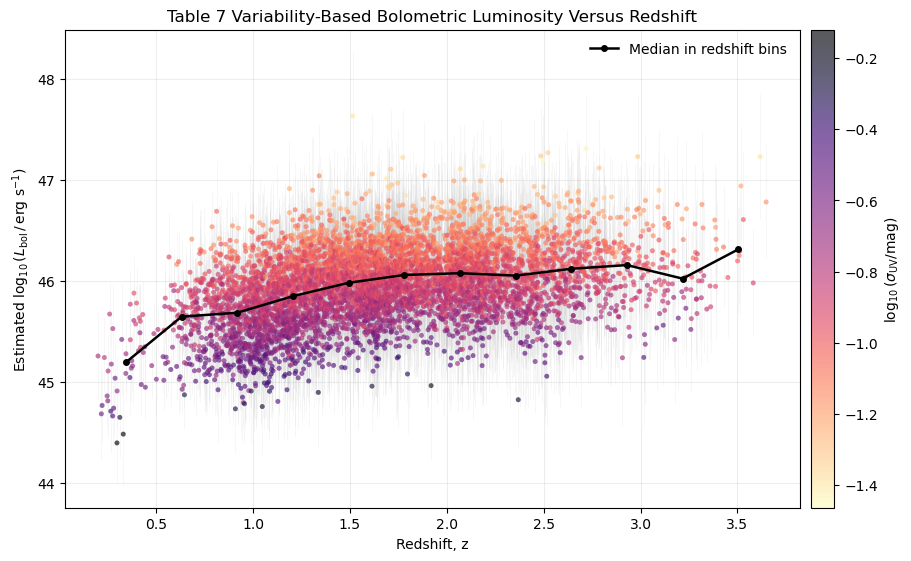

In [11]:
plot_name = sdss_name[valid]
plot_z = redshift[valid]
plot_log_lbol = log_lbol[valid]
plot_log_lbol_err = log_lbol_err[valid]
plot_log_l2500 = log_l2500[valid]
plot_log_sigma_uv = log_sigma_uv[valid]

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

err_mask = np.isfinite(plot_log_lbol_err) & (plot_log_lbol_err > 0)
ax.errorbar(
    plot_z[err_mask],
    plot_log_lbol[err_mask],
    yerr=plot_log_lbol_err[err_mask],
    fmt="none",
    ecolor="0.78",
    elinewidth=0.5,
    alpha=0.18,
    zorder=1,
)

scatter = ax.scatter(
    plot_z,
    plot_log_lbol,
    c=plot_log_sigma_uv,
    s=13,
    cmap="magma_r",
    alpha=0.65,
    linewidths=0,
    zorder=2,
)

bins = np.linspace(np.nanmin(plot_z), np.nanmax(plot_z), 13)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_medians = []
bin_counts = []
for left, right in zip(bins[:-1], bins[1:]):
    in_bin = (plot_z >= left) & (plot_z < right)
    bin_counts.append(in_bin.sum())
    bin_medians.append(np.nanmedian(plot_log_lbol[in_bin]) if in_bin.any() else np.nan)

bin_medians = np.array(bin_medians)
bin_counts = np.array(bin_counts)
median_mask = np.isfinite(bin_medians) & (bin_counts > 0)
ax.plot(
    bin_centers[median_mask],
    bin_medians[median_mask],
    color="black",
    marker="o",
    markersize=4,
    linewidth=1.8,
    label="Median in redshift bins",
    zorder=3,
)

ax.set_xlabel("Redshift, z")
ax.set_ylabel(r"Estimated $\log_{10}(L_{\rm bol}\,/\,\mathrm{erg\ s^{-1}})$")
ax.set_title("Table 7 Variability-Based Bolometric Luminosity Versus Redshift")
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="best")

cbar = fig.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label(r"$\log_{10}(\sigma_{\rm UV} / \mathrm{mag})$")

figure_path = OUTPUT_DIR / "table7_variability_logLbol_vs_redshift.png"
fig.savefig(figure_path, dpi=220)
print(f"Saved figure to {figure_path}")
plt.show()

## Optional: Inspect The Most And Least Luminous Objects

In [12]:
order = np.argsort(plot_log_lbol)
extreme_indices = np.concatenate([order[:5], order[-5:]])

print("SDSS Name             z       logL2500  logLbol")
print("-----------------------------------------------")
for idx in extreme_indices:
    print(
        f"{plot_name[idx]:<20} "
        f"{plot_z[idx]:6.3f} "
        f"{plot_log_l2500[idx]:9.3f} "
        f"{plot_log_lbol[idx]:8.3f}"
    )

SDSS Name             z       logL2500  logLbol
-----------------------------------------------
231625.39-002225.5    0.297    43.681   44.393
210200.42+000501.8    0.330    43.768   44.480
013517.55-001939.0    0.312    43.935   44.647
010123.64+010045.3    0.275    43.948   44.660
023957.04+003242.8    0.217    43.969   44.681
221018.97-001558.9    2.986    46.519   47.231
023011.28+005913.6    2.486    46.526   47.237
015208.72-000932.0    2.522    46.557   47.269
223604.95+005439.8    2.720    46.599   47.311
230224.00+004853.6    1.514    46.923   47.635


## Chimera Benchmark Comparison

The cells below reproduce the benchmark comparison using `chimera_mass_retrieval_by_logLbol.csv`. This is separate from the Table 7 calculation above.

In [13]:
CHIMERA_BENCHMARK_PATH = ROOT / "chimera_mass_retrieval_by_logLbol.csv"

with CHIMERA_BENCHMARK_PATH.open(newline="") as handle:
    chimera_rows = list(csv.DictReader(handle))

chimera_object_id = np.array([row["object_id"] for row in chimera_rows])
chimera_redshift = np.array([as_float(row["redshift"]) for row in chimera_rows])
chimera_log_lbol_qso = np.array([as_float(row["logLbol_QSO"]) for row in chimera_rows])
chimera_log_lbol_weighted = np.array([as_float(row["logLbol_chimera"]) for row in chimera_rows])
chimera_qso_weight = np.array([as_float(row["chimera_QSO_weight"]) for row in chimera_rows])

chimera_valid = np.isfinite(chimera_redshift) & np.isfinite(chimera_log_lbol_qso)

print(f"Loaded {len(chimera_rows):,} Chimera benchmark rows")
print(f"Valid redshift and logLbol_QSO values: {chimera_valid.sum():,}")
print(f"Redshift range: {np.nanmin(chimera_redshift):.3f} to {np.nanmax(chimera_redshift):.3f}")
print(f"logLbol_QSO range: {np.nanmin(chimera_log_lbol_qso):.3f} to {np.nanmax(chimera_log_lbol_qso):.3f}")
print(f"logLbol_chimera range: {np.nanmin(chimera_log_lbol_weighted):.3f} to {np.nanmax(chimera_log_lbol_weighted):.3f}")

Loaded 13,558 Chimera benchmark rows
Valid redshift and logLbol_QSO values: 13,558
Redshift range: 0.078 to 4.869
logLbol_QSO range: 44.116 to 48.098
logLbol_chimera range: 40.650 to 44.999


Saved figure to /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/16_log_bolometric_luminosity_redshift/chimera_benchmark_logLbol_vs_redshift.png


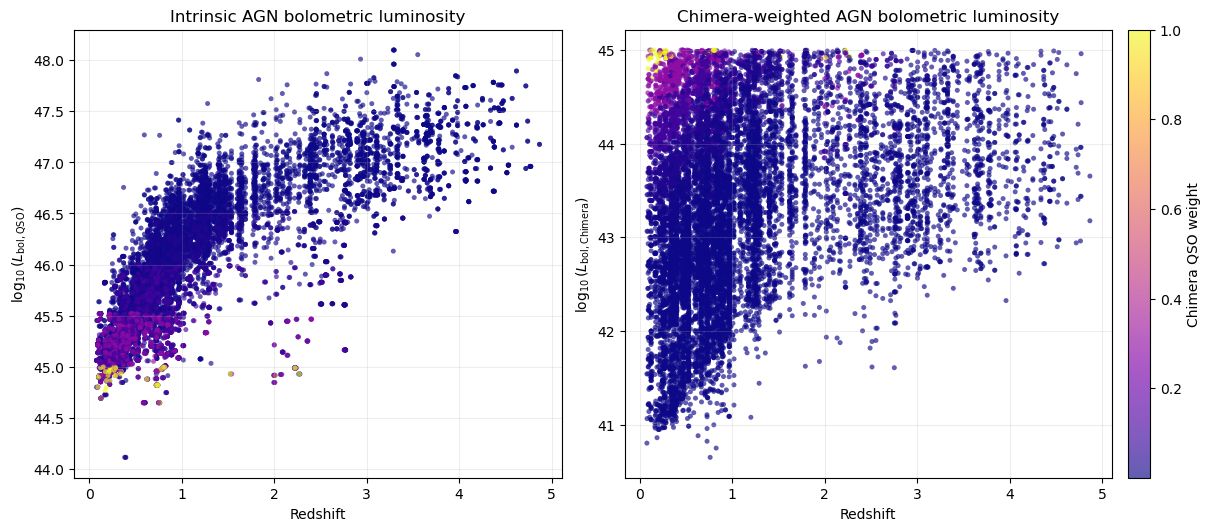

In [14]:
chimera_plot_z = chimera_redshift[chimera_valid]
chimera_plot_log_lbol_qso = chimera_log_lbol_qso[chimera_valid]
chimera_plot_log_lbol_weighted = chimera_log_lbol_weighted[chimera_valid]
chimera_plot_qso_weight = chimera_qso_weight[chimera_valid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, constrained_layout=True)

scatter = axes[0].scatter(
    chimera_plot_z,
    chimera_plot_log_lbol_qso,
    c=chimera_plot_qso_weight,
    s=13,
    cmap="plasma",
    alpha=0.65,
    linewidths=0,
)
axes[0].set_title("Intrinsic AGN bolometric luminosity")
axes[0].set_ylabel(r"$\log_{10}(L_{\rm bol,QSO})$")

axes[1].scatter(
    chimera_plot_z,
    chimera_plot_log_lbol_weighted,
    c=chimera_plot_qso_weight,
    s=13,
    cmap="plasma",
    alpha=0.65,
    linewidths=0,
)
axes[1].set_title("Chimera-weighted AGN bolometric luminosity")
axes[1].set_ylabel(r"$\log_{10}(L_{\rm bol,Chimera})$")

for ax in axes:
    ax.set_xlabel("Redshift")
    ax.grid(alpha=0.22)

cbar = fig.colorbar(scatter, ax=axes, pad=0.015)
cbar.set_label("Chimera QSO weight")

chimera_comparison_path = OUTPUT_DIR / "chimera_benchmark_logLbol_vs_redshift.png"
fig.savefig(chimera_comparison_path, dpi=220)
print(f"Saved figure to {chimera_comparison_path}")
plt.show()

Saved figure to /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/16_log_bolometric_luminosity_redshift/chimera_benchmark_logLbol_QSO_vs_redshift.png


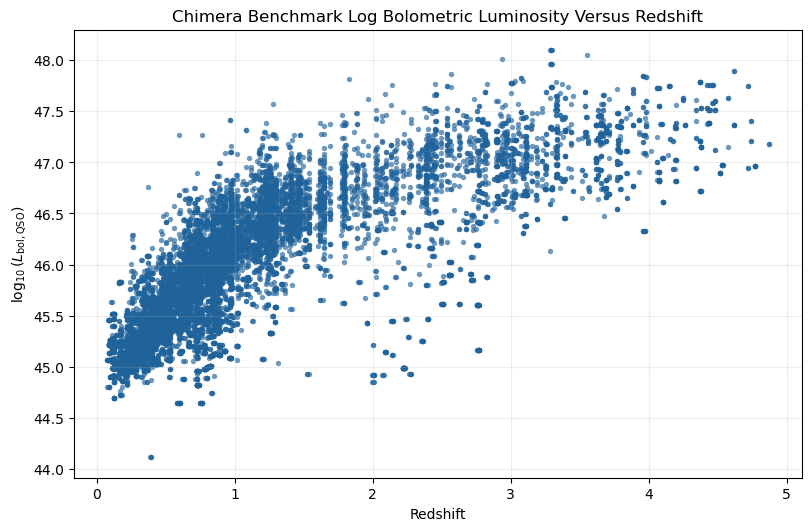

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.2), constrained_layout=True)
ax.scatter(
    chimera_plot_z,
    chimera_plot_log_lbol_qso,
    s=15,
    color="#20639B",
    alpha=0.65,
    linewidths=0,
)
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$\log_{10}(L_{\rm bol,QSO})$")
ax.set_title("Chimera Benchmark Log Bolometric Luminosity Versus Redshift")
ax.grid(alpha=0.22)

chimera_single_panel_path = OUTPUT_DIR / "chimera_benchmark_logLbol_QSO_vs_redshift.png"
fig.savefig(chimera_single_panel_path, dpi=220)
print(f"Saved figure to {chimera_single_panel_path}")
plt.show()